# EcoSentry Unified Pipeline
This executable pipeline simulates the complete data flow. It starts with an initial payload event (Arch5), encrypts/encodes it (Arch6), evaluates its energy footprint across scenarios (Arch7), and maps delivery rates across different network topologies (Arch8). 

In [ ]:
import os
import sys
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dataclasses import asdict

sys.path.append(os.path.abspath(os.path.join("..", "src")))

from ecosentry.config import load_canonical_config
from ecosentry.contracts import Arch5Result
from ecosentry.arch6_payload import AlertPayloadCodec, DeviceMetadata
from ecosentry.arch7_energy import simulate_30d, default_energy_model, scenario_definitions, EnergyModel
from ecosentry.arch8_network import run_campaign, build_topology_corbett, build_topology_seshachalam, build_topology_sundarbans

config = load_canonical_config(os.path.abspath(os.path.join("..", "config", "canonical_config.json")))
Path(os.path.abspath(os.path.join("..", "results"))).mkdir(exist_ok=True)


## 1. Input Event & Arch6 Payload Encoding
We simulate a gunshot detection event and push it through the codec.

Encoded Payload Size (Enveloped): 106 bytes


C:\Users\abhis\AppData\Local\Temp\ipykernel_17140\2818394801.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=sizes, palette="viridis")


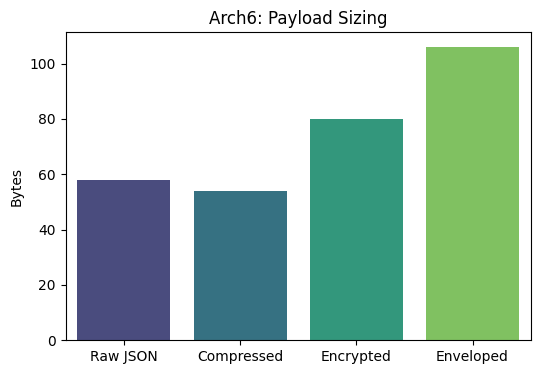

In [4]:
# Initial mock input payload
event_payload = Arch5Result(timestamp_ms=1700000000000, class_id=0, confidence=0.98)
device_meta = DeviceMetadata(device_id="node-xyz", location_hash="geo-123", firmware_version="2.0.1")

# Arch6 Encoding
encryption_key = os.urandom(32)
hmac_key = os.urandom(32)
codec = AlertPayloadCodec(config, encryption_key, hmac_key)
encoded_alert = codec.encode(event_payload, device_meta)

actual_payload_size = encoded_alert.size_report.enveloped_bytes
print(f"Encoded Payload Size (Enveloped): {actual_payload_size} bytes")

sizes = [encoded_alert.size_report.raw_json_bytes, encoded_alert.size_report.compressed_bytes, 
         encoded_alert.size_report.encrypted_bytes, actual_payload_size]
labels = ["Raw JSON", "Compressed", "Encrypted", "Enveloped"]

plt.figure(figsize=(6, 4))
sns.barplot(x=labels, y=sizes, palette="viridis")
plt.title("Arch6: Payload Sizing")
plt.ylabel("Bytes")
plt.show()

## 2. Arch7 Energy Simulation
Using the **exact payload size** established above, we estimate energy decay over a 30-day mission.

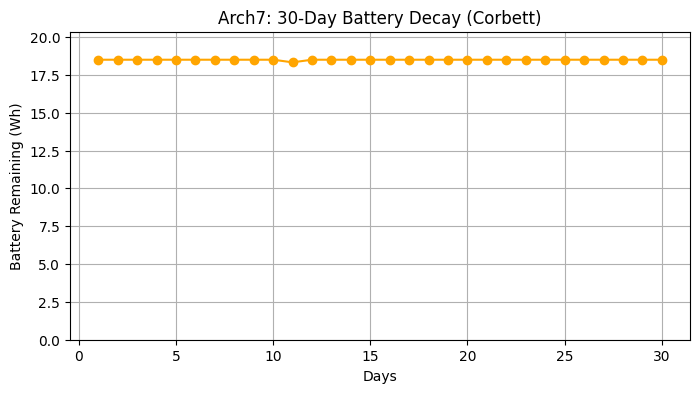

In [5]:
scenarios = scenario_definitions()
corbett_scenario = scenarios['corbett']

# Base model updated with the ACTUAL payload size from Arch6
base_model = default_energy_model(config, sf=9)
pipeline_model = EnergyModel(**{**asdict(base_model), "payload_bytes": actual_payload_size})

mission_res = simulate_30d(corbett_scenario, pipeline_model, sf=9)

days = list(range(1, 31))
battery_traj = [x['battery_wh'] for x in mission_res["battery_trajectory"]]

plt.figure(figsize=(8,4))
plt.plot(days, battery_traj, marker="o", color="orange")
plt.title(f"Arch7: 30-Day Battery Decay ({corbett_scenario.name})")
plt.xlabel("Days")
plt.ylabel("Battery Remaining (Wh)")
plt.grid(True)
plt.ylim(0, base_model.battery_wh * 1.1)
plt.show()

## 3. Arch8 Network Topologies
Finally, we assess whether our real payload size affects the packet delivery rate in 3 differing geographic mesh topologies.

Saved unified pipeline report to results/pipeline_report.json


C:\Users\abhis\AppData\Local\Temp\ipykernel_17140\1814273082.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=deliveries, palette="magma")


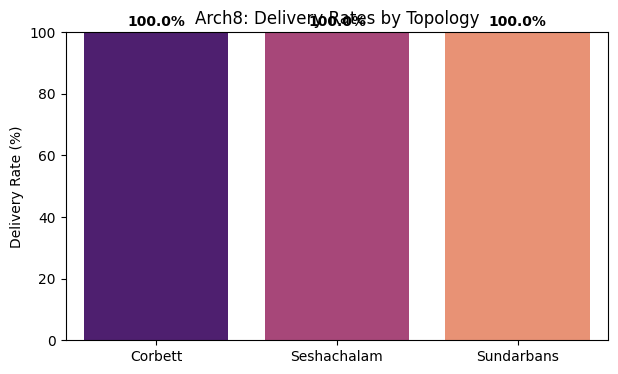

In [7]:
queue_limit = int(config.data["network"]["queue_limit"])

# Use the actual payload size established uniformly by the pipeline
corbett_net = run_campaign(
    build_topology_corbett(queue_limit),
    config,
    payload_bytes=actual_payload_size,
    sf=9,
    messages=5000,
    interference_probability=0.01,
    congestion_multiplier=1.0,
    relay_failure_probability=0.05,
)
sesha_net = run_campaign(
    build_topology_seshachalam(queue_limit),
    config,
    payload_bytes=actual_payload_size,
    sf=9,
    messages=5000,
    interference_probability=0.01,
    congestion_multiplier=1.0,
    relay_failure_probability=0.05,
)
sundar_net = run_campaign(
    build_topology_sundarbans(queue_limit),
    config,
    payload_bytes=actual_payload_size,
    sf=9,
    messages=5000,
    interference_probability=0.01,
    congestion_multiplier=1.0,
    relay_failure_probability=0.05,
)

results_json = {
    "arch6": {
        "payload_size_bytes": actual_payload_size,
        "size_report": {
            "raw": encoded_alert.size_report.raw_json_bytes,
            "compressed": encoded_alert.size_report.compressed_bytes,
            "encrypted": encoded_alert.size_report.encrypted_bytes,
            "enveloped": encoded_alert.size_report.enveloped_bytes,
        },
    },
    "arch7": {
        "scenario": corbett_scenario.name,
        "final_soc_percent": mission_res["final_soc_percent"],
        "survived_30_days": mission_res["survived_30_days"],
    },
    "arch8": {
        "corbett": {
            "delivery_rate": corbett_net.delivery_rate,
            "packet_loss_rate": corbett_net.packet_loss_rate,
        },
        "seshachalam": {
            "delivery_rate": sesha_net.delivery_rate,
            "packet_loss_rate": sesha_net.packet_loss_rate,
        },
        "sundarbans": {
            "delivery_rate": sundar_net.delivery_rate,
            "packet_loss_rate": sundar_net.packet_loss_rate,
        },
    },
}

with open(os.path.abspath(os.path.join("..", "results", "pipeline_report.json")), "w", encoding="utf-8") as f:
    json.dump(results_json, f, indent=2)

print("Saved unified pipeline report to results/pipeline_report.json")

deliveries = [corbett_net.delivery_rate * 100, sesha_net.delivery_rate * 100, sundar_net.delivery_rate * 100]
labels = ["Corbett", "Seshachalam", "Sundarbans"]

plt.figure(figsize=(7,4))
sns.barplot(x=labels, y=deliveries, palette="magma")
plt.title("Arch8: Delivery Rates by Topology")
plt.ylabel("Delivery Rate (%)")
plt.ylim(0, 100)
for i, v in enumerate(deliveries):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')
plt.show()